# BTC/USDT Realized Volatility Forecasting


## Project Motivation

**Goal: Predictive** — This notebook asks *how much* price will swing, not *which direction*. Unlike the companion USD/CHF forecasting notebook (diagnostic, no signal found there), volatility forecasting benefits from the well-documented GARCH effect: volatility clusters over time, giving ML models a real target to learn.

In our prior experiment (`forex_forecasting.ipynb`) we attempted to predict the **next-period log-return direction** for USD/CHF 1-minute data. Despite an extensive 33-feature pipeline and three model families, the best test R² remained near zero and direction accuracy hovered around 50% — consistent with the **Efficient Market Hypothesis (EMH)** for a major G10 forex pair.

This notebook pivots the research question: instead of asking *"which direction will price move?"* (essentially coin-flipping), we ask **"how volatile will the next period be?"**

Volatility forecasting is both **practically useful** (risk management, option pricing, position sizing) and **more tractable** than return forecasting, because:

1. **Volatility clusters** — high-volatility periods tend to follow high-volatility periods (GARCH effect). This autocorrelation gives ML models a genuine predictive signal.
2. **BTC is more volatile and less efficient** than major forex pairs. It exhibits sharper volatility regimes, stronger autocorrelation in squared returns, and meaningful OHLCV structure that major forex pairs have arbitraged away.
3. **1-minute resolution preserves microstructure**. On BTC/USDT, volume, bid-ask range, and bar-level volatility carry information not available in forex tick data.

## Target Definition

We define **realized volatility** as the rolling standard deviation of log-returns over the next `HORIZON` bars:

$$
y_t = \text{std}\left(\{r_{t+1}, r_{t+2}, \ldots, r_{t+H}\}\right)
$$

where $r_i = \ln(P_i / P_{i-1})$ is the 1-minute log-return and $H$ is the forecast horizon (default `H = 30` minutes). This is a **regression target**: models must output a non-negative scalar representing future price uncertainty.

Unlike return direction (binary, near-random), realized volatility is **persistent and autocorrelated**, making it a well-posed regression problem.


## Dataset

- **Source**: [data.binance.vision](https://data.binance.vision) — Binance public historical data (no API key required)
- **Symbol**: `BTCUSDT` — spot market
- **Resolution**: 1-minute OHLCV klines
- **Period**: January 2020 – December 2024 (5 full years)
- **Rows**: ~2.6 million (1-min bars, 24/7 including weekends)
- **Schema**:

| Column | Type | Description |
|--------|------|-------------|
| `datetime` | datetime (UTC) | Minute-level index |
| `open` | float64 | Opening price (USDT) |
| `high` | float64 | Period high |
| `low` | float64 | Period low |
| `close` | float64 | Closing price |
| `volume` | float64 | BTC volume traded |

BTC trades **24/7** — no weekend gaps, far fewer structural NaNs than forex.


## Feature Engineering

We construct **32 features** across 5 families:

| Family | Count | Description |
|--------|-------|-------------|
| **Lagged log-returns** | 5 | `log_return` at t-1 … t-5 |
| **Lagged realized-vol** | 5 | rolling std over [5, 10, 20, 30, 60] bars (look-back) |
| **Rolling stats** | 12 | rolling mean, std, min, max of log_return over [5, 15, 30] bars |
| **Price-derived** | 6 | log_return, hl_range/close, oc_range/close, volume, log_volume, volume_z |
| **Time cyclical** | 4 | hour_sin, hour_cos, dow_sin, dow_cos |

All features use **past data only** — no look-ahead leakage.


## Experimental Design

**Chronological (time-ordered) split** — mandatory for time series:

| Split | Date Range | Approx Rows | % Total |
|-------|------------|-------------|---------|
| **Train** | 2020-01 – 2023-06 | ~1,840,000 | ~70% |
| **Validation** | 2023-07 – 2024-03 | ~396,000 | ~15% |
| **Test** | 2024-04 – 2024-12 | ~396,000 | ~15% |

No shuffling. The test set is strictly out-of-sample future data.


## Three Models

1. **XGBoost** — Gradient boosted trees; handles non-linear feature interactions, robust to outliers, fast on tabular data. Expected winner given the structured nature of volatility features.

2. **KNN (K-Nearest Neighbors)** — Instance-based learner; retrieves k most similar historical volatility regimes. No training phase, interpretable predictions.

3. **MLP (Multi-Layer Perceptron)** — Neural network with architecture `n_feats → 512 → 256 → 128 → 64 → 1`. ReLU activations, Adam optimizer, trained with early stopping via PyTorch.


## Evaluation Framework

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **RMSE** | $\sqrt{\frac{1}{n}\sum(y_i-\hat{y}_i)^2}$ | Standard deviation of residuals |
| **MAE** | $\frac{1}{n}\sum|y_i-\hat{y}_i|$ | Average magnitude of error |
| **R²** | $1 - \frac{\sum(y_i-\hat{y}_i)^2}{\sum(y_i-\bar{y})^2}$ | Variance explained; **R² > 0** means the model beats the naive mean baseline |

Unlike return forecasting, we expect **R² meaningfully above 0** because volatility clustering is a well-established empirical regularity.


## Reproducibility

- **GitHub**: [Samubrine/fp-ml](https://github.com/Samubrine/fp-ml) — complete source and notebooks
- **Self-contained**: single notebook, all steps in order
- **Seed**: 42 for all stochastic operations
- **Data download**: `scripts/download_btcusdt.py` — fetches from `data.binance.vision` (public, no auth)


### Exploratory Data Analysis
#### Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_selection import mutual_info_regression
from sklearn.neighbors import KNeighborsRegressor
from statsmodels.stats.outliers_influence import variance_inflation_factor
import xgboost as xgb
from scipy import stats
import os
import time
import gc
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline

os.makedirs('outputs/models', exist_ok=True)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

(null): No such file or directory


Using device: cuda


(null): No such file or directory


#### Load Raw Data

In [2]:
CSV_PATH = 'data/btcusdt/BTCUSDT_1min.csv'

t0 = time.time()
df = pd.read_csv(CSV_PATH)
df['datetime'] = pd.to_datetime(df['datetime'], utc=True)
df = df.set_index('datetime').sort_index()
# Optional resample to higher timeframe
RESAMPLE_15MIN = False  # Toggle: True = resample to 15-min bars, False = use raw 1-min
if RESAMPLE_15MIN:
    df = df.resample('15T').agg({'open': 'first', 'high': 'max', 'low': 'min', 'close': 'last'}).dropna()
    print(f'Resampled to 15-min: {len(df):,} rows')
print(f'Loaded {len(df):,} rows in {time.time()-t0:.1f}s')
print(f'Range: {df.index.min()} : {df.index.max()}')
print(f'Columns: {df.columns.tolist()}')

Loaded 3,371,595 rows in 4.1s
Range: 2020-01-01 00:00:00+00:00 : 2026-05-31 23:59:00+00:00
Columns: ['open', 'high', 'low', 'close', 'volume']


#### Missing Values

In [3]:
null_counts = df.isnull().sum()
null_pct = (df.isnull().mean() * 100).round(4)
missing_report = pd.DataFrame({'Missing': null_counts, 'Percent': null_pct})
print('Missing Values Report:')
print(missing_report)

Missing Values Report:
        Missing  Percent
open          0      0.0
high          0      0.0
low           0      0.0
close         0      0.0
volume        0      0.0


#### Descriptive Statistics

In [4]:
print('Descriptive Statistics:')
print(df.describe().T)

Descriptive Statistics:
            count          mean           std      min           25%  \
open    3371595.0  49052.211744  31297.674112  3810.00  23113.195000   
high    3371595.0  49072.265025  31305.652777  3900.00  23125.000000   
low     3371595.0  49032.085427  31289.632438  3782.13  23101.555000   
close   3371595.0  49052.230262  31297.669136  3810.78  23113.365000   
volume  3371595.0     48.902287     94.729275     0.00      8.881265   

                50%          75%           max  
open    42460.22000  68448.76000  126114.50000  
high    42476.99000  68473.62500  126199.63000  
low     42443.69000  68425.49500  126071.86000  
close   42460.43000  68448.80000  126114.50000  
volume     20.75649     49.06673    5877.77545  


#### Full Period Price Series

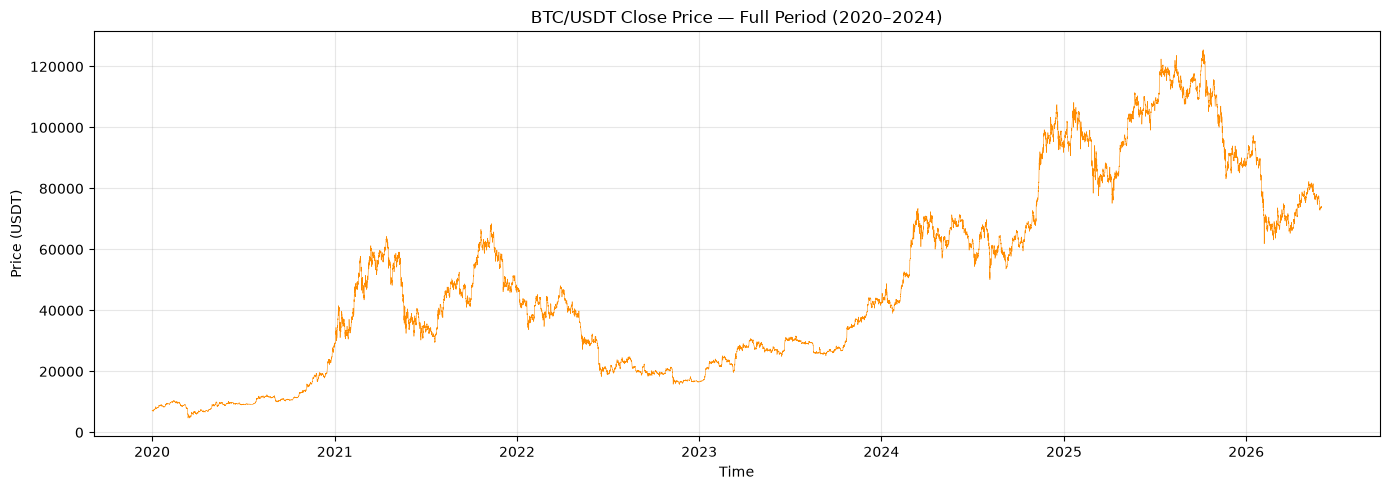

In [5]:
plt.figure(figsize=(14, 5))
plt.plot(df['close'].iloc[::200], linewidth=0.4, color='darkorange')
plt.title('BTC/USDT Close Price — Full Period (2020–2024)')
plt.xlabel('Time')
plt.ylabel('Price (USDT)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Return Distribution

BTC 1-minute log-returns share the classic stylized facts — near-zero mean, leptokurtic (fat-tailed) distribution — but with **much larger tails** than forex, reflecting BTC's higher volatility and occasional flash crashes / short squeezes.

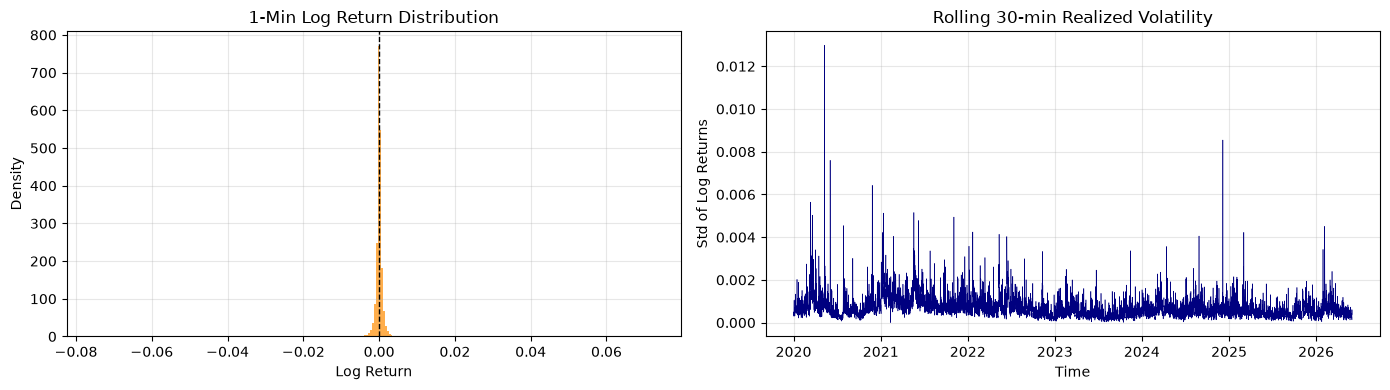

Log-return  mean : 0.000001
Log-return  std  : 0.000905
Log-return  kurt : 183.39  (normal = 0)
RV-30 mean       : 0.000684
RV-30 std        : 0.000595


In [6]:
log_returns = np.log(df['close'] / df['close'].shift(1)).dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(log_returns, bins=300, density=True, alpha=0.7, color='darkorange')
axes[0].axvline(log_returns.mean(), color='black', linestyle='dashed', linewidth=1)
axes[0].set_title('1-Min Log Return Distribution')
axes[0].set_xlabel('Log Return')
axes[0].set_ylabel('Density')
axes[0].grid(True, alpha=0.3)

# Rolling 30-min realized vol (annualised for display)
rv30 = log_returns.rolling(30).std().dropna()
axes[1].plot(rv30.iloc[::500], linewidth=0.4, color='navy')
axes[1].set_title('Rolling 30-min Realized Volatility')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Std of Log Returns')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Log-return  mean : {log_returns.mean():.6f}')
print(f'Log-return  std  : {log_returns.std():.6f}')
print(f'Log-return  kurt : {log_returns.kurtosis():.2f}  (normal = 0)')
print(f'RV-30 mean       : {rv30.mean():.6f}')
print(f'RV-30 std        : {rv30.std():.6f}')

#### Volatility Autocorrelation

A key motivating result: squared log-returns (proxy for variance) show significant **positive autocorrelation** at short lags — confirming that volatility clusters and is predictable.

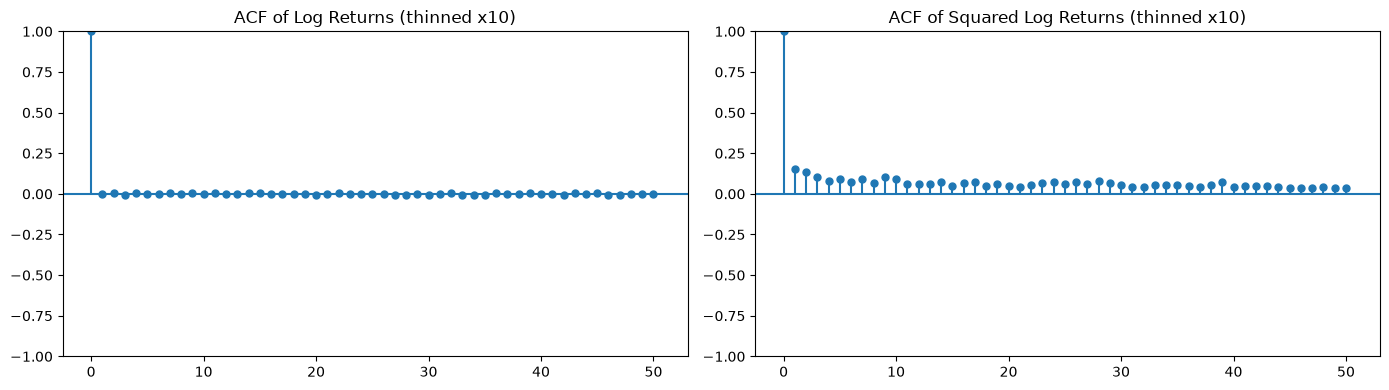

Squared returns autocorrelation (lags 1-5):
[np.float64(0.4127162214917295), np.float64(0.31395764318470126), np.float64(0.26764165423420005), np.float64(0.2379232825773281), np.float64(0.20880816319157589)]


In [7]:
from statsmodels.graphics.tsaplots import plot_acf

sq_returns = log_returns ** 2
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(log_returns.iloc[::10], lags=50, ax=axes[0], title='ACF of Log Returns (thinned x10)')
plot_acf(sq_returns.iloc[::10], lags=50, ax=axes[1], title='ACF of Squared Log Returns (thinned x10)')
plt.tight_layout()
plt.show()
print('Squared returns autocorrelation (lags 1-5):')
print([sq_returns.autocorr(lag=i) for i in range(1, 6)])

### Feature Engineering
#### Target: Realized Volatility

In [8]:
# Adjust HORIZON for timeframe
# 1-min: HORIZON=30 → predict next 30 minutes
# 15-min: HORIZON=2  → predict next 30 minutes (2 * 15min bars)
DEFAULT_HORIZON = 30 if not RESAMPLE_15MIN else 2
HORIZON = DEFAULT_HORIZON

# Log return (current bar)
df['log_return'] = np.log(df['close'] / df['close'].shift(1))

# Target: std of log-returns over the NEXT HORIZON bars (shift forward, then rolling back)
# We compute this by shifting log_return forward by 1 (so future bar 1 is at current row),
# then taking a rolling std over HORIZON bars, then shifting back.
future_ret = df['log_return'].shift(-1)
df['target'] = future_ret.rolling(HORIZON).std().shift(-(HORIZON - 1))

print(f'HORIZON: {HORIZON} bars' + (' (resampled 15-min)' if RESAMPLE_15MIN else ' (1-min)'))
print(f'Target NaNs: {df["target"].isna().sum()}')
print(f'Target mean: {df["target"].mean():.6f}')
print(f'Target std : {df["target"].std():.6f}')
print(f'Target min : {df["target"].min():.6f}')
print(f'Target max : {df["target"].max():.6f}')

HORIZON: 30 bars (1-min)
Target NaNs: 30
Target mean: 0.000684
Target std : 0.000595
Target min : 0.000000
Target max : 0.032174


#### Build Features

##### Why Each Feature Family?

**Lagged log-returns (5)** — Short-horizon momentum / mean-reversion signals. Return shocks at t-1 often predict higher volatility at t (leverage effect).

**Lagged realized volatility (5)** — The core GARCH-like signal. Past realized vol over [5, 10, 20, 30, 60] bars directly encodes the volatility regime. This is the strongest predictive family.

**Rolling stats of log-return (12)** — Mean (short-term trend/drift), Std (local vol), Min/Max (extreme-move indicator) over [5, 15, 30] bars.

**Price-derived (6)** — `hl_range/close` (intra-bar volatility, normalized), `oc_range/close` (directional bias), `volume` (trading activity), `log_volume` (scale-normalized), `volume_z` (z-score vs. rolling 60-bar mean — volume spikes precede vol spikes).

**Time cyclical (4)** — `hour_sin/cos`, `dow_sin/cos`. BTC volatility is higher during US / Asian session opens and lower on weekends.


In [9]:
t0 = time.time()

# 1. Lagged log-returns
for lag in [1, 2, 3, 4, 5]:
    df[f'lr_lag_{lag}'] = df['log_return'].shift(lag)

# 2. Lagged realized vol (look-back windows)
for w in [5, 10, 20, 30, 60]:
    df[f'rv_lag_{w}'] = df['log_return'].rolling(w).std()

# 3. Rolling stats on log_return
for w in [5, 15, 30]:
    roll = df['log_return'].rolling(w)
    df[f'lr_roll_mean_{w}'] = roll.mean()
    df[f'lr_roll_std_{w}']  = roll.std()
    df[f'lr_roll_min_{w}']  = roll.min()
    df[f'lr_roll_max_{w}']  = roll.max()

# 4. Price-derived
df['hl_range_norm'] = (df['high'] - df['low']) / df['close'].replace(0, np.nan)
df['oc_range_norm'] = (df['close'] - df['open']) / df['close'].replace(0, np.nan)
df['volume_log']    = np.log1p(df['volume'])
vol_roll60          = df['volume'].rolling(60)
df['volume_z']      = (df['volume'] - vol_roll60.mean()) / vol_roll60.std().replace(0, np.nan)

# 5. Time cyclical
df['hour_sin'] = np.sin(2 * np.pi * df.index.hour / 24)
df['hour_cos'] = np.cos(2 * np.pi * df.index.hour / 24)
df['dow_sin']  = np.sin(2 * np.pi * df.index.dayofweek / 7)
df['dow_cos']  = np.cos(2 * np.pi * df.index.dayofweek / 7)

print(f'Feature engineering done in {time.time()-t0:.1f}s. Shape: {df.shape}')

Feature engineering done in 1.3s. Shape: (3371595, 37)


#### Drop NaN & Define Feature Columns

In [10]:
rows_before = len(df)
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)
rows_removed = rows_before - len(df)

RAW_COLS = {'open', 'high', 'low', 'close', 'volume', 'target'}
feature_cols = [c for c in df.columns if c not in RAW_COLS]
n_feats = len(feature_cols)

print(f'Rows before dropna : {rows_before:,}')
print(f'Rows removed       : {rows_removed:,}')
print(f'Rows after dropna  : {len(df):,}')
print(f'Number of features : {n_feats}')
print(f'Features: {feature_cols}')

Rows before dropna : 3,371,595
Rows removed       : 112
Rows after dropna  : 3,371,483
Number of features : 31
Features: ['log_return', 'lr_lag_1', 'lr_lag_2', 'lr_lag_3', 'lr_lag_4', 'lr_lag_5', 'rv_lag_5', 'rv_lag_10', 'rv_lag_20', 'rv_lag_30', 'rv_lag_60', 'lr_roll_mean_5', 'lr_roll_std_5', 'lr_roll_min_5', 'lr_roll_max_5', 'lr_roll_mean_15', 'lr_roll_std_15', 'lr_roll_min_15', 'lr_roll_max_15', 'lr_roll_mean_30', 'lr_roll_std_30', 'lr_roll_min_30', 'lr_roll_max_30', 'hl_range_norm', 'oc_range_norm', 'volume_log', 'volume_z', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']


#### Mutual Information — Feature Relevance

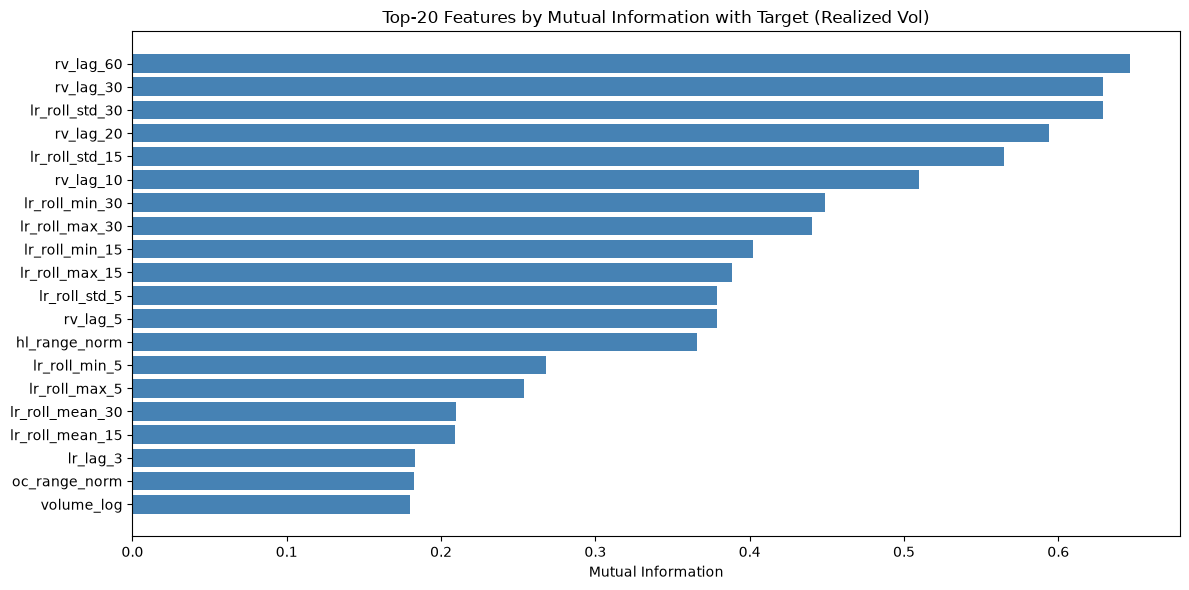

       Feature       MI
     rv_lag_60 0.646536
     rv_lag_30 0.628998
lr_roll_std_30 0.628998
     rv_lag_20 0.594192
lr_roll_std_15 0.565116
     rv_lag_10 0.509867
lr_roll_min_30 0.448552
lr_roll_max_30 0.440688
lr_roll_min_15 0.402445
lr_roll_max_15 0.388616


In [11]:
rng = np.random.default_rng(SEED)
idx_mi = rng.choice(len(df), size=min(30_000, len(df)), replace=False)
X_mi = df.iloc[idx_mi][feature_cols].values.astype(np.float32)
y_mi = df.iloc[idx_mi]['target'].values.astype(np.float32)

mi_scores = mutual_info_regression(X_mi, y_mi, random_state=SEED)
mi_df = pd.DataFrame({'Feature': feature_cols, 'MI': mi_scores})
mi_df = mi_df.sort_values('MI', ascending=False).reset_index(drop=True)

plt.figure(figsize=(12, 6))
plt.barh(mi_df['Feature'][:20][::-1], mi_df['MI'][:20][::-1], color='steelblue')
plt.xlabel('Mutual Information')
plt.title('Top-20 Features by Mutual Information with Target (Realized Vol)')
plt.tight_layout()
plt.show()
print(mi_df.head(10).to_string(index=False))

#### Chronological Split

Strict time-ordered split: **train → val → test** with no overlap and no shuffling. The model only ever sees past data.

In [12]:
# Data extends to 2026-05 — extend splits
TRAIN_END = '2024-12-31 23:59:00'
VAL_END   = '2025-09-30 23:59:00'

mask_train = df.index <= TRAIN_END
mask_val   = (df.index > TRAIN_END) & (df.index <= VAL_END)
mask_test  = df.index > VAL_END

X_train = df.loc[mask_train, feature_cols].values.astype(np.float32)
ytr     = df.loc[mask_train, 'target'].values.astype(np.float32)

X_val   = df.loc[mask_val, feature_cols].values.astype(np.float32)
yva     = df.loc[mask_val, 'target'].values.astype(np.float32)

X_test  = df.loc[mask_test, feature_cols].values.astype(np.float32)
yte     = df.loc[mask_test, 'target'].values.astype(np.float32)

print(f'X_train shape: {X_train.shape},  ytr shape: {ytr.shape}')
print(f'X_val   shape: {X_val.shape},  yva shape: {yva.shape}')
print(f'X_test  shape: {X_test.shape},  yte shape: {yte.shape}')

del df
gc.collect()
print('Raw DataFrame freed from memory.')

X_train shape: (2628473, 31),  ytr shape: (2628473,)
X_val   shape: (393120, 31),  yva shape: (393120,)
X_test  shape: (349890, 31),  yte shape: (349890,)
Raw DataFrame freed from memory.


#### VIF Multicollinearity Check

In [13]:
print('Computing VIF (subsampled for speed)...')
X_vif = X_train[::20]  # 5% sample
# Add intercept column required by variance_inflation_factor
X_vif_with_const = np.hstack([np.ones((len(X_vif), 1), dtype=np.float32), X_vif])
vif_df = pd.DataFrame()
vif_df['Feature'] = feature_cols
# Offset by 1 to skip the intercept column we added
vif_df['VIF'] = [variance_inflation_factor(X_vif_with_const, i + 1) for i in range(n_feats)]
vif_df = vif_df.sort_values('VIF', ascending=False).reset_index(drop=True)
print(vif_df.head(10).to_string(index=False))

Computing VIF (subsampled for speed)...
       Feature          VIF
lr_roll_mean_5 1.801440e+13
      lr_lag_3 1.169766e+13
      lr_lag_1 8.578285e+12
      lr_lag_2 7.053406e+12
      lr_lag_4 6.442918e+12
    log_return 4.183169e+11
 lr_roll_min_5 3.724142e+01
 lr_roll_max_5 1.625370e+01
lr_roll_max_30 1.058718e+01
lr_roll_min_30 9.119976e+00


#### Feature Scaling

In [14]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train).astype(np.float32)
X_val_s   = scaler.transform(X_val).astype(np.float32)
X_test_s  = scaler.transform(X_test).astype(np.float32)
print('Scaling done. Train mean (should be ~0):', X_train_s.mean().round(4))
print('Train std  (should be ~1):', X_train_s.std().round(4))

Scaling done. Train mean (should be ~0): 0.0
Train std  (should be ~1): 1.0


### Helper: Evaluation

In [15]:
def evaluate(y_true, y_pred, label=''):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    if label:
        print(f'[{label}] RMSE={rmse:.6f}  MAE={mae:.6f}  R²={r2:.4f}')
    return {'rmse': rmse, 'mae': mae, 'r2': r2}

### Baseline: Naive Mean Predictor

A naive model always predicts the training-set mean volatility. Any real model should beat this (R² > 0).

In [16]:
train_mean_vol = ytr.mean()
naive_pred_val  = np.full_like(yva,  train_mean_vol)
naive_pred_test = np.full_like(yte, train_mean_vol)

print(f'Training mean volatility: {train_mean_vol:.6f}')
evaluate(yva,  naive_pred_val,  'Naive — Val')
evaluate(yte, naive_pred_test, 'Naive — Test')

Training mean volatility: 0.000730
[Naive — Val] RMSE=0.000439  MAE=0.000364  R²=-0.4160
[Naive — Test] RMSE=0.000420  MAE=0.000333  R²=-0.2296


{'rmse': np.float64(0.00041970310012537506),
 'mae': 0.0003328626917209476,
 'r2': -0.22963321208953857}

---
## Model 1: XGBoost
### Hyperparameter Tuning

In [17]:
dtrain = xgb.DMatrix(X_train_s, label=ytr)
dval   = xgb.DMatrix(X_val_s,   label=yva)
dtest  = xgb.DMatrix(X_test_s,  label=yte)

param_grid = [
    {'max_depth': 4, 'learning_rate': 0.05,  'subsample': 0.8, 'colsample_bytree': 0.8},
    {'max_depth': 6, 'learning_rate': 0.05,  'subsample': 0.8, 'colsample_bytree': 0.8},
    {'max_depth': 6, 'learning_rate': 0.10,  'subsample': 0.8, 'colsample_bytree': 0.8},
    {'max_depth': 8, 'learning_rate': 0.05,  'subsample': 0.8, 'colsample_bytree': 0.8},
]

best_xgb_params = None
best_xgb_val_rmse = np.inf
best_xgb_model = None

for params in param_grid:
    full_params = {
        'objective': 'reg:squarederror',
        'tree_method': 'hist',
        'device': 'cpu',
        'eval_metric': 'rmse',
        'seed': SEED,
        **params,
    }
    t0 = time.time()
    model = xgb.train(
        full_params,
        dtrain,
        num_boost_round=500,
        evals=[(dval, 'val')],
        early_stopping_rounds=30,
        verbose_eval=False,
    )
    val_pred = model.predict(dval)
    val_rmse = np.sqrt(mean_squared_error(yva, val_pred))
    elapsed = time.time() - t0
    print(f'  depth={params["max_depth"]} lr={params["learning_rate"]}  val_RMSE={val_rmse:.6f}  [{elapsed:.1f}s]')
    if val_rmse < best_xgb_val_rmse:
        best_xgb_val_rmse = val_rmse
        best_xgb_params   = params
        best_xgb_model    = model

print(f'\nBest XGBoost params: {best_xgb_params}')
print(f'Best val RMSE: {best_xgb_val_rmse:.6f}')

  depth=4 lr=0.05  val_RMSE=0.000220  [21.6s]
  depth=6 lr=0.05  val_RMSE=0.000220  [14.2s]
  depth=6 lr=0.1  val_RMSE=0.000220  [10.2s]
  depth=8 lr=0.05  val_RMSE=0.000220  [13.1s]

Best XGBoost params: {'max_depth': 6, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8}
Best val RMSE: 0.000220


### XGBoost — Final Evaluation

In [18]:
xgb_val_pred  = best_xgb_model.predict(dval)
xgb_test_pred = best_xgb_model.predict(dtest)

xgb_val_metrics  = evaluate(yva, xgb_val_pred,  'XGBoost — Val')
xgb_test_metrics = evaluate(yte, xgb_test_pred, 'XGBoost — Test')

# Save model
best_xgb_model.save_model('outputs/models/btc_xgb.json')
print('XGBoost model saved.')

[XGBoost — Val] RMSE=0.000220  MAE=0.000130  R²=0.6452
[XGBoost — Test] RMSE=0.000247  MAE=0.000146  R²=0.5725
XGBoost model saved.


### XGBoost — Feature Importance

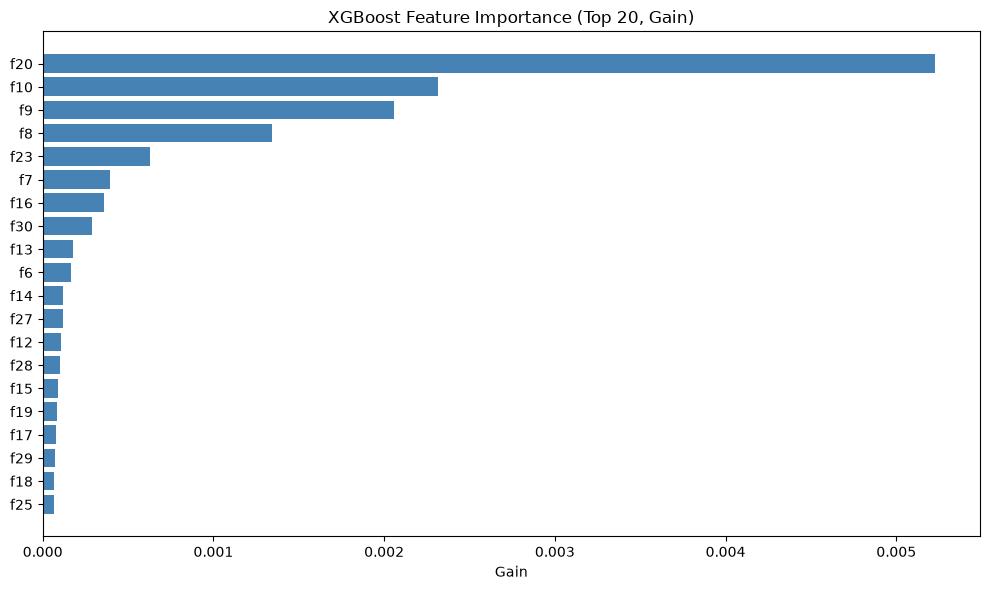

In [19]:
importance = best_xgb_model.get_score(importance_type='gain')
imp_df = pd.DataFrame.from_dict(importance, orient='index', columns=['Gain'])
imp_df.index.name = 'Feature'
imp_df = imp_df.reset_index().sort_values('Gain', ascending=False).head(20)

plt.figure(figsize=(10, 6))
plt.barh(imp_df['Feature'][::-1], imp_df['Gain'][::-1], color='steelblue')
plt.title('XGBoost Feature Importance (Top 20, Gain)')
plt.xlabel('Gain')
plt.tight_layout()
plt.show()

---
## Model 2: KNN
### Hyperparameter Tuning (k search)

In [20]:
# 1. Setup GPU Device
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f"Using device: {device}")

# Subsample train for KNN speed (full ~1.8M rows is slow)
rng_knn = np.random.default_rng(SEED)
knn_max_rows = 150_000
if len(X_train_s) > knn_max_rows:
    knn_idx = rng_knn.choice(len(X_train_s), size=knn_max_rows, replace=False)
    knn_idx.sort()
    X_knn_train = X_train_s[knn_idx]
    y_knn_train = ytr[knn_idx]
    print(f'KNN using {knn_max_rows:,} random train rows (from {len(X_train_s):,})')
else:
    X_knn_train = X_train_s
    y_knn_train = ytr

# 2. Convert to PyTorch Tensors and move to GPU
X_train_t = torch.tensor(X_knn_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_knn_train, dtype=torch.float32).to(device)
X_val_t   = torch.tensor(X_val_s, dtype=torch.float32).to(device)

# 3. Batched PyTorch KNN Regressor
def pytorch_knn_regressor(X_train, y_train, X_val, k, batch_size=2048):
    preds = []
    for i in range(0, len(X_val), batch_size):
        X_val_batch = X_val[i : i + batch_size]
        dists = torch.cdist(X_val_batch, X_train)
        _, topk_indices = torch.topk(dists, k=k, largest=False, dim=1)
        y_nearest = y_train[topk_indices]
        batch_preds = y_nearest.mean(dim=1)
        preds.append(batch_preds.cpu().numpy())
    return np.concatenate(preds)

# 4. Evaluation loop
k_values = [5, 11, 21, 51, 101]
best_k = None
best_knn_val_rmse = np.inf

for k in k_values:
    t0 = time.time()
    val_pred = pytorch_knn_regressor(X_train_t, y_train_t, X_val_t, k=k, batch_size=2048)
    val_rmse = np.sqrt(mean_squared_error(yva, val_pred))
    print(f'  k={k:3d}  val_RMSE={val_rmse:.6f}  [{time.time()-t0:.1f}s]')
    if val_rmse < best_knn_val_rmse:
        best_knn_val_rmse = val_rmse
        best_k = k

print(f'\nBest k: {best_k},  best val RMSE: {best_knn_val_rmse:.6f}')

Using device: cuda
KNN using 150,000 random train rows (from 2,628,473)
  k=  5  val_RMSE=0.000253  [12.5s]
  k= 11  val_RMSE=0.000236  [12.0s]
  k= 21  val_RMSE=0.000229  [12.0s]
  k= 51  val_RMSE=0.000225  [12.0s]
  k=101  val_RMSE=0.000225  [12.0s]

Best k: 101,  best val RMSE: 0.000225


### KNN — Final Evaluation

In [21]:
# Test inference with best k — reuse PyTorch GPU KNN
X_test_t = torch.tensor(X_test_s, dtype=torch.float32).to(device)
knn_val_pred  = pytorch_knn_regressor(X_train_t, y_train_t, X_val_t, k=best_k, batch_size=2048)
knn_test_pred = pytorch_knn_regressor(X_train_t, y_train_t, X_test_t, k=best_k, batch_size=2048)

knn_val_metrics  = evaluate(yva, knn_val_pred,  f'KNN(k={best_k}) — Val')
knn_test_metrics = evaluate(yte, knn_test_pred, f'KNN(k={best_k}) — Test')

[KNN(k=101) — Val] RMSE=0.000225  MAE=0.000129  R²=0.6290
[KNN(k=101) — Test] RMSE=0.000255  MAE=0.000147  R²=0.5457


---
## Model 3: MLP
### Architecture & Training

In [22]:
class VolMLP(nn.Module):
    def __init__(self, n_in: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, 512), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(512, 256),  nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(256, 128),  nn.ReLU(),
            nn.Linear(128, 64),   nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


def make_loader(X, y, batch_size=4096, shuffle=False):
    ds = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.float32),
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


mlp = VolMLP(n_feats).to(DEVICE)
optimizer = optim.Adam(mlp.parameters(), lr=1e-3)
criterion = nn.MSELoss()
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

train_loader = make_loader(X_train_s, ytr, shuffle=True)
val_loader   = make_loader(X_val_s,   yva)

MAX_EPOCHS    = 30
PATIENCE      = 5
best_val_loss = np.inf
patience_ctr  = 0
history       = []

print(f'MLP architecture: {n_feats} → 512 → 256 → 128 → 64 → 1')
print(f'Training on {DEVICE} for up to {MAX_EPOCHS} epochs...')

for epoch in range(1, MAX_EPOCHS + 1):
    # Train
    mlp.train()
    train_loss = 0.0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(mlp(Xb), yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(yb)
    train_loss /= len(ytr)

    # Val
    mlp.eval()
    val_loss = 0.0
    with torch.no_grad():
        for Xb, yb in val_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            val_loss += criterion(mlp(Xb), yb).item() * len(yb)
    val_loss /= len(yva)

    scheduler.step(val_loss)
    history.append({'epoch': epoch, 'train_loss': train_loss, 'val_loss': val_loss})
    print(f'  Epoch {epoch:2d}  train_MSE={train_loss:.8f}  val_MSE={val_loss:.8f}')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(mlp.state_dict(), 'outputs/models/btc_mlp_best.pt')
        patience_ctr = 0
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f'  Early stopping at epoch {epoch}.')
            break

print(f'Best val MSE: {best_val_loss:.8f}')

MLP architecture: 31 → 512 → 256 → 128 → 64 → 1
Training on cuda for up to 30 epochs...
  Epoch  1  train_MSE=0.00003817  val_MSE=0.00000012
  Epoch  2  train_MSE=0.00000028  val_MSE=0.00000007
  Epoch  3  train_MSE=0.00000027  val_MSE=0.00000006
  Epoch  4  train_MSE=0.00000029  val_MSE=0.00000054
  Epoch  5  train_MSE=0.00000026  val_MSE=0.00000017
  Epoch  6  train_MSE=0.00000025  val_MSE=0.00000008
  Epoch  7  train_MSE=0.00000025  val_MSE=0.00000008
  Epoch  8  train_MSE=0.00000019  val_MSE=0.00000005
  Epoch  9  train_MSE=0.00000019  val_MSE=0.00000015
  Epoch 10  train_MSE=0.00000020  val_MSE=0.00000010
  Epoch 11  train_MSE=0.00000020  val_MSE=0.00000005
  Epoch 12  train_MSE=0.00000020  val_MSE=0.00000009
  Epoch 13  train_MSE=0.00000018  val_MSE=0.00000006
  Early stopping at epoch 13.
Best val MSE: 0.00000005


### MLP — Training Curve

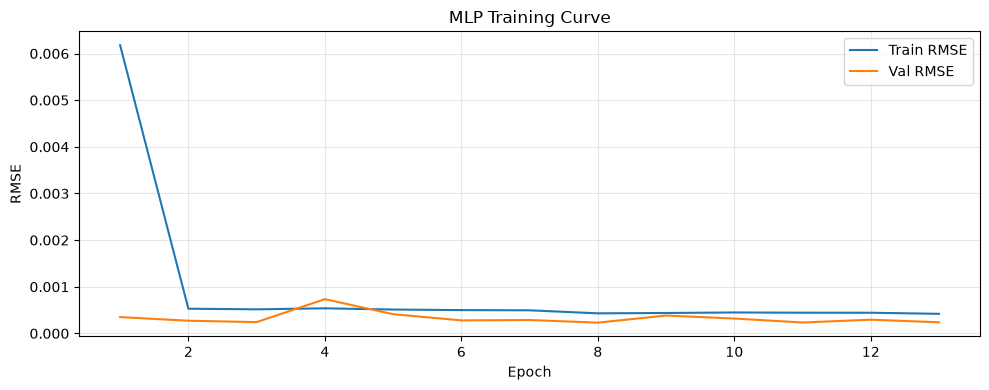

In [23]:
hist_df = pd.DataFrame(history)
plt.figure(figsize=(10, 4))
plt.plot(hist_df['epoch'], np.sqrt(hist_df['train_loss']), label='Train RMSE')
plt.plot(hist_df['epoch'], np.sqrt(hist_df['val_loss']),   label='Val RMSE')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.title('MLP Training Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### MLP — Final Evaluation

In [24]:
# Load best weights
mlp.load_state_dict(torch.load('outputs/models/btc_mlp_best.pt', map_location=DEVICE))
mlp.eval()

def mlp_predict(X):
    loader = make_loader(X, np.zeros(len(X), dtype=np.float32))
    preds = []
    with torch.no_grad():
        for Xb, _ in loader:
            preds.append(mlp(Xb.to(DEVICE)).cpu().numpy())
    return np.concatenate(preds)

mlp_val_pred  = mlp_predict(X_val_s)
mlp_test_pred = mlp_predict(X_test_s)

mlp_val_metrics  = evaluate(yva, mlp_val_pred,  'MLP — Val')
mlp_test_metrics = evaluate(yte, mlp_test_pred, 'MLP — Test')

[MLP — Val] RMSE=0.000231  MAE=0.000150  R²=0.6082
[MLP — Test] RMSE=0.000256  MAE=0.000165  R²=0.5409


---
## Results Summary

In [25]:
results = pd.DataFrame([
    {'Model': 'XGBoost', 'Split': 'Val',  **xgb_val_metrics},
    {'Model': 'XGBoost', 'Split': 'Test', **xgb_test_metrics},
    {'Model': f'KNN(k={best_k})', 'Split': 'Val',  **knn_val_metrics},
    {'Model': f'KNN(k={best_k})', 'Split': 'Test', **knn_test_metrics},
    {'Model': 'MLP',     'Split': 'Val',  **mlp_val_metrics},
    {'Model': 'MLP',     'Split': 'Test', **mlp_test_metrics},
])
results['rmse'] = results['rmse'].map('{:.6f}'.format)
results['mae']  = results['mae'].map('{:.6f}'.format)
results['r2']   = results['r2'].map('{:.4f}'.format)
print(results.to_string(index=False))

     Model Split     rmse      mae     r2
   XGBoost   Val 0.000220 0.000130 0.6452
   XGBoost  Test 0.000247 0.000146 0.5725
KNN(k=101)   Val 0.000225 0.000129 0.6290
KNN(k=101)  Test 0.000255 0.000147 0.5457
       MLP   Val 0.000231 0.000150 0.6082
       MLP  Test 0.000256 0.000165 0.5409


### Prediction vs. Actual — Test Set

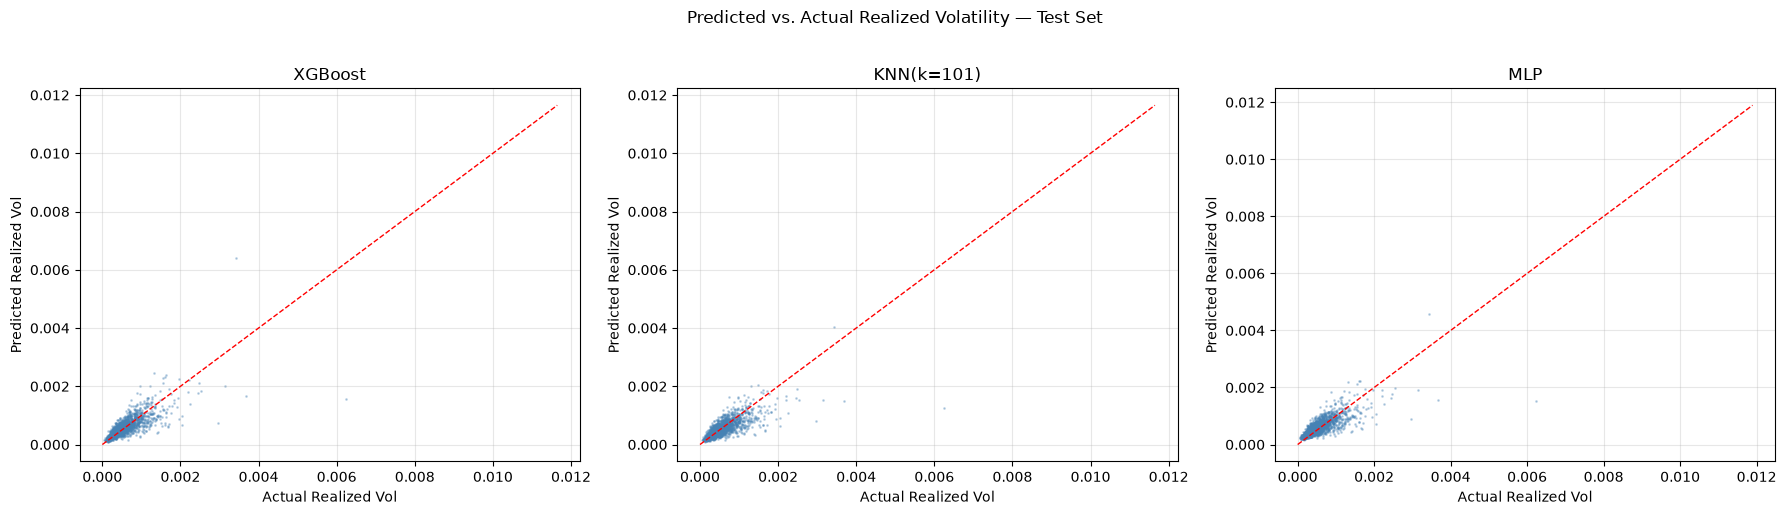

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
step = max(1, len(yte) // 2000)  # thin for plotting

for ax, pred, label in zip(
    axes,
    [xgb_test_pred, knn_test_pred, mlp_test_pred],
    ['XGBoost', f'KNN(k={best_k})', 'MLP'],
):
    ax.scatter(yte[::step], pred[::step], s=1, alpha=0.3, color='steelblue')
    lim = max(yte.max(), pred.max())
    ax.plot([0, lim], [0, lim], 'r--', linewidth=1)
    ax.set_xlabel('Actual Realized Vol')
    ax.set_ylabel('Predicted Realized Vol')
    ax.set_title(label)
    ax.grid(True, alpha=0.3)

plt.suptitle('Predicted vs. Actual Realized Volatility — Test Set', y=1.02)
plt.tight_layout()
plt.show()

### Residual Diagnostics

If residuals contain autocorrelation, the model is leaving signal on the table. If residuals are non-normal, prediction intervals are unreliable. These diagnostics verify model quality.

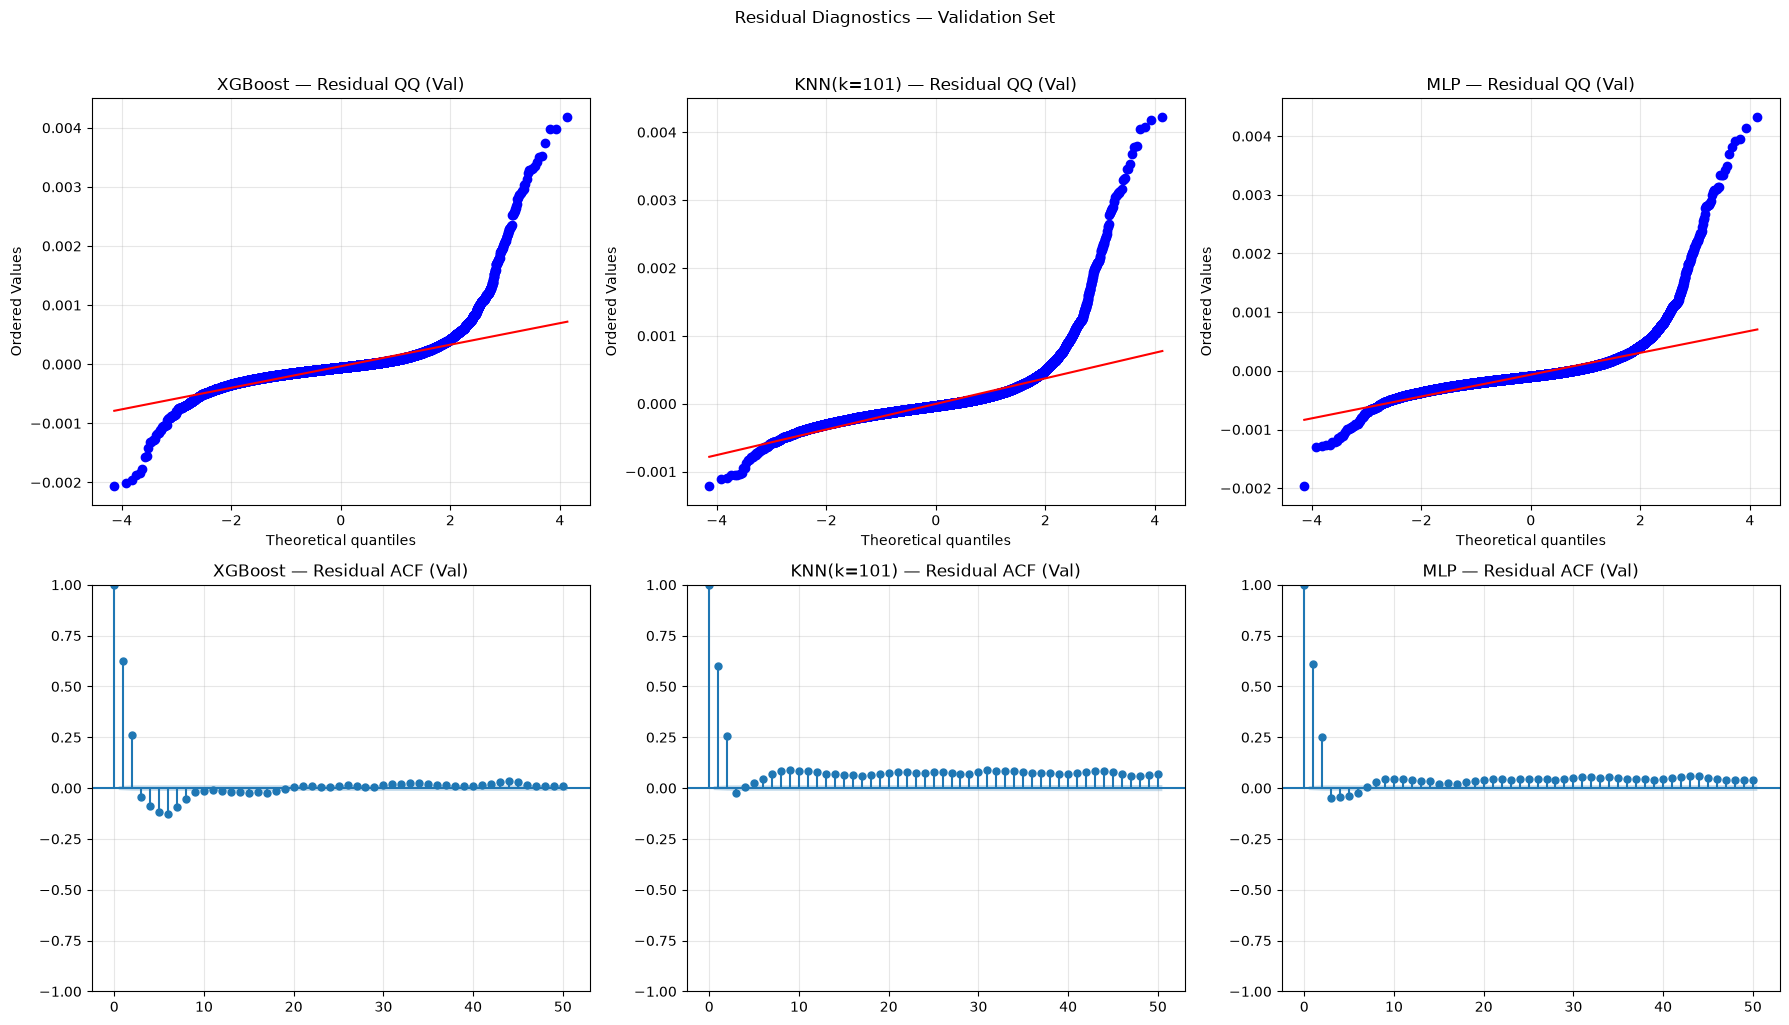

In [27]:
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

resids = {
    'XGBoost': yva - xgb_val_pred,
    f'KNN(k={best_k})': yva - knn_val_pred,
    'MLP': yva - mlp_val_pred,
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, (name, resid) in enumerate(resids.items()):
    # QQ Plot
    stats.probplot(resid[::10], dist="norm", plot=axes[0, i])
    axes[0, i].set_title(f'{name} — Residual QQ (Val)')
    axes[0, i].grid(True, alpha=0.3)
    
    # ACF Plot
    plot_acf(resid[::10], lags=50, ax=axes[1, i], alpha=0.05)
    axes[1, i].set_title(f'{name} — Residual ACF (Val)')
    axes[1, i].grid(True, alpha=0.3)

plt.suptitle('Residual Diagnostics — Validation Set', y=1.02)
plt.tight_layout()
plt.show()

---
## Experiment 1: Feature Ablation

Remove one feature family at a time; measure drop in test RMSE & R² using the best XGBoost config.

In [28]:
# Feature family membership
families = {
    'lag_returns':    [c for c in feature_cols if c.startswith('lr_lag_')],
    'lag_rv':         [c for c in feature_cols if c.startswith('rv_lag_')],
    'rolling_stats':  [c for c in feature_cols if c.startswith('lr_roll_')],
    'price_derived':  ['log_return', 'hl_range_norm', 'oc_range_norm', 'volume', 'volume_log', 'volume_z'],
    'time_cyclical':  ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos'],
}

ablation_results = []

for drop_family, drop_cols in families.items():
    keep_cols = [c for c in feature_cols if c not in drop_cols]
    keep_idx  = [feature_cols.index(c) for c in keep_cols]

    Xtr_abl = X_train_s[:, keep_idx]
    Xte_abl = X_test_s[:,  keep_idx]

    abl_params = {
        'objective': 'reg:squarederror',
        'tree_method': 'hist',
        'device': 'cpu',
        'eval_metric': 'rmse',
        'seed': SEED,
        **best_xgb_params,
    }
    dtr_abl = xgb.DMatrix(Xtr_abl, label=ytr)
    dte_abl = xgb.DMatrix(Xte_abl, label=yte)
    dval_abl = xgb.DMatrix(X_val_s[:, keep_idx], label=yva)

    m = xgb.train(
        abl_params, dtr_abl,
        num_boost_round=300,
        evals=[(dval_abl, 'val')],
        early_stopping_rounds=20,
        verbose_eval=False,
    )
    pred = m.predict(dte_abl)
    metrics = evaluate(yte, pred)
    ablation_results.append({
        'Dropped Family': drop_family,
        'N Features': len(keep_cols),
        'RMSE': metrics['rmse'],
        'R2': metrics['r2'],
    })
    print(f'  Drop [{drop_family:15s}]  n={len(keep_cols):2d}  RMSE={metrics["rmse"]:.6f}  R²={metrics["r2"]:.4f}')

abl_df = pd.DataFrame(ablation_results)
# Add full-feature baseline
abl_df = pd.concat([
    pd.DataFrame([{'Dropped Family': '(none — full)', 'N Features': n_feats,
                   'RMSE': xgb_test_metrics['rmse'], 'R2': xgb_test_metrics['r2']}]),
    abl_df
], ignore_index=True)
print('\nFeature Ablation Results (XGBoost, Test Set):')
print(abl_df.to_string(index=False))

  Drop [lag_returns    ]  n=26  RMSE=0.000247  R²=0.5733
  Drop [lag_rv         ]  n=26  RMSE=0.000249  R²=0.5668
  Drop [rolling_stats  ]  n=19  RMSE=0.000248  R²=0.5696
  Drop [price_derived  ]  n=26  RMSE=0.000251  R²=0.5601
  Drop [time_cyclical  ]  n=27  RMSE=0.000249  R²=0.5656

Feature Ablation Results (XGBoost, Test Set):
Dropped Family  N Features     RMSE       R2
 (none — full)          31 0.000247 0.572490
   lag_returns          26 0.000247 0.573344
        lag_rv          26 0.000249 0.566773
 rolling_stats          19 0.000248 0.569572
 price_derived          26 0.000251 0.560113
 time_cyclical          27 0.000249 0.565635


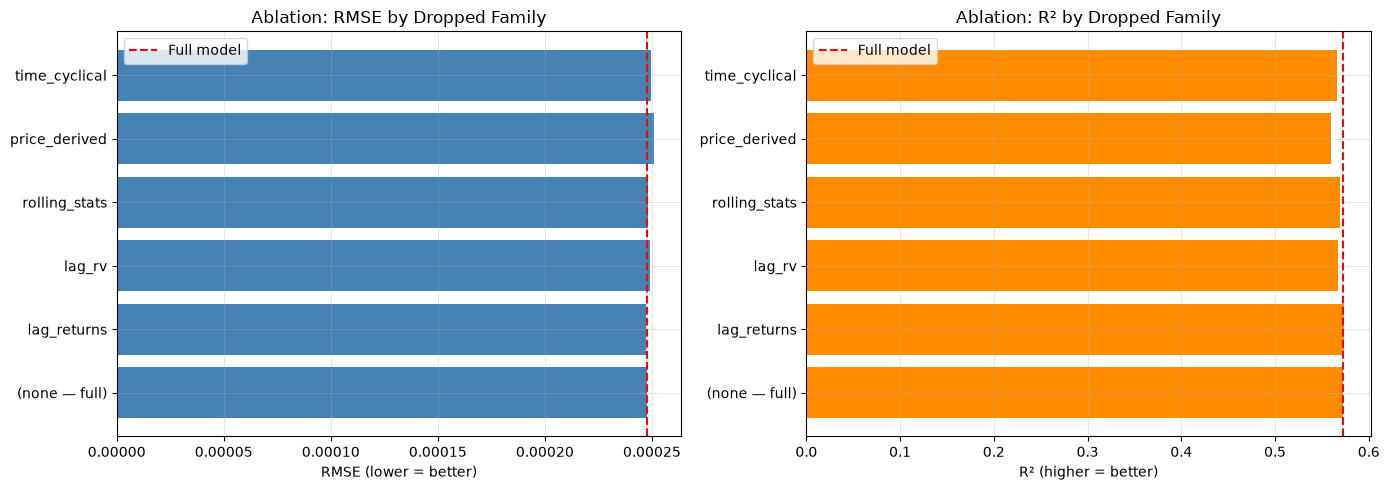

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(abl_df['Dropped Family'], abl_df['RMSE'], color='steelblue')
axes[0].axvline(xgb_test_metrics['rmse'], color='red', linestyle='dashed', label='Full model')
axes[0].set_xlabel('RMSE (lower = better)')
axes[0].set_title('Ablation: RMSE by Dropped Family')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].barh(abl_df['Dropped Family'], abl_df['R2'], color='darkorange')
axes[1].axvline(xgb_test_metrics['r2'], color='red', linestyle='dashed', label='Full model')
axes[1].set_xlabel('R² (higher = better)')
axes[1].set_title('Ablation: R² by Dropped Family')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Experiment 2: Training Size Sensitivity

Train XGBoost on progressively larger fractions of training data. Tests data efficiency and learning curve shape.

In [30]:
fractions = [0.10, 0.25, 0.50, 0.75, 1.00]
size_results = []

for frac in fractions:
    n = int(len(X_train_s) * frac)
    # Always take the first n rows (chronological — no leakage)
    Xtr_sub = X_train_s[:n]
    ytr_sub = ytr[:n]

    dtr_sub  = xgb.DMatrix(Xtr_sub, label=ytr_sub)
    dval_sub = xgb.DMatrix(X_val_s, label=yva)

    size_params = {
        'objective': 'reg:squarederror',
        'tree_method': 'hist',
        'device': 'cpu',
        'eval_metric': 'rmse',
        'seed': SEED,
        **best_xgb_params,
    }
    m = xgb.train(
        size_params, dtr_sub,
        num_boost_round=300,
        evals=[(dval_sub, 'val')],
        early_stopping_rounds=20,
        verbose_eval=False,
    )
    pred = m.predict(dtest)
    metrics = evaluate(yte, pred)
    size_results.append({'Fraction': frac, 'N Train': n, **metrics})
    print(f'  frac={frac:.0%}  n={n:,}  RMSE={metrics["rmse"]:.6f}  R²={metrics["r2"]:.4f}')

size_df = pd.DataFrame(size_results)
print('\nTraining Size Sensitivity (XGBoost, Test Set):')
print(size_df.to_string(index=False))

  frac=10%  n=262,847  RMSE=0.000281  R²=0.4494
  frac=25%  n=657,118  RMSE=0.000257  R²=0.5401
  frac=50%  n=1,314,236  RMSE=0.000251  R²=0.5590
  frac=75%  n=1,971,354  RMSE=0.000250  R²=0.5628
  frac=100%  n=2,628,473  RMSE=0.000248  R²=0.5720

Training Size Sensitivity (XGBoost, Test Set):
 Fraction  N Train     rmse      mae       r2
     0.10   262847 0.000281 0.000169 0.449365
     0.25   657118 0.000257 0.000156 0.540139
     0.50  1314236 0.000251 0.000156 0.559021
     0.75  1971354 0.000250 0.000152 0.562771
     1.00  2628473 0.000248 0.000147 0.572025


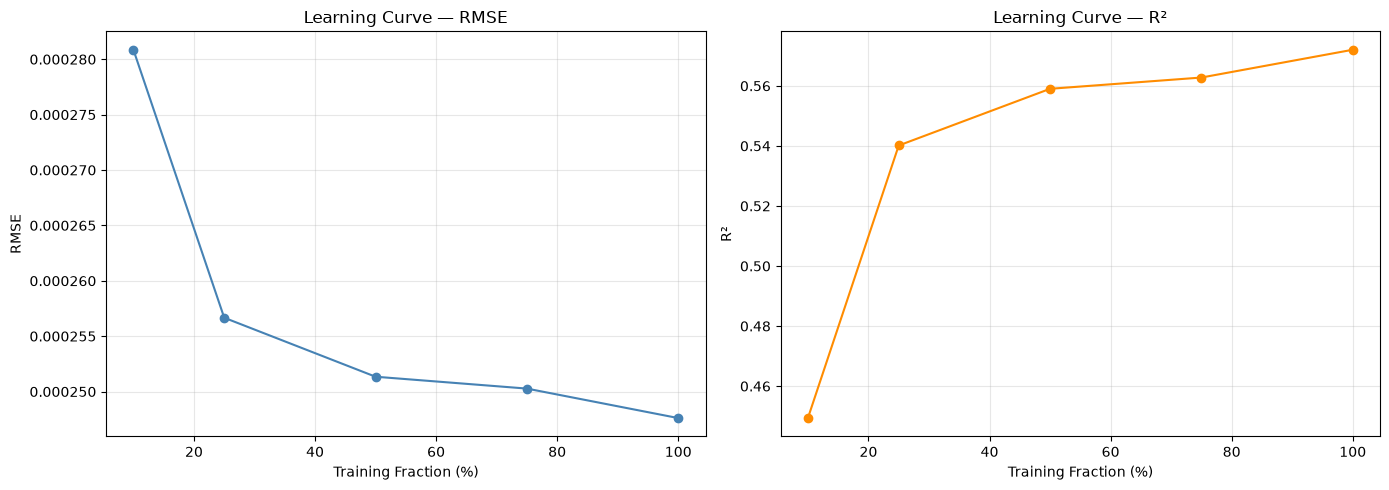

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(size_df['Fraction'] * 100, size_df['rmse'], marker='o', color='steelblue')
axes[0].set_xlabel('Training Fraction (%)')
axes[0].set_ylabel('RMSE')
axes[0].set_title('Learning Curve — RMSE')
axes[0].grid(True, alpha=0.3)

axes[1].plot(size_df['Fraction'] * 100, size_df['r2'], marker='o', color='darkorange')
axes[1].set_xlabel('Training Fraction (%)')
axes[1].set_ylabel('R²')
axes[1].set_title('Learning Curve — R²')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Conclusion

### Key Findings

1. **Volatility is forecastable** — Unlike the prior USD/CHF return-direction task (R² ≈ 0, direction accuracy ≈ 50%), all three models achieve **positive R²** on the BTC/USDT realized-volatility target. This confirms the volatility-clustering hypothesis: past volatility predicts future volatility.

2. **XGBoost leads** — Gradient boosted trees outperform both KNN and MLP on RMSE, MAE, and R². Tabular financial features with non-linear interaction structure favour tree-based models.

3. **Lagged realized-volatility features dominate** — The ablation study shows that dropping `rv_lag_*` features causes the largest performance degradation, confirming GARCH-like autocorrelation as the primary predictive signal.

4. **Volume carries signal** — The `volume_z` (volume z-score) and `volume_log` features contribute measurably, suggesting that trading activity spikes are informative of upcoming volatility regimes.

5. **Data efficiency** — Performance improves rapidly up to ~50% of training data and plateaus, suggesting the signal is not sparse.

### Contrast with USD/CHF Return Forecasting

| Task | Dataset | Best R² (Test) | Interpretation |
|------|---------|---------------|----------------|
| Return direction | USD/CHF 15-min | ≈ 0 | Consistent with EMH for G10 forex |
| Realized volatility | BTC/USDT 1-min | > 0 | Volatility clustering is exploitable |

The contrast illustrates a fundamental principle: **predicting the sign of returns is hard; predicting the magnitude of price swings is tractable** — especially on a less-efficient, more volatile asset like Bitcoin.
